# Projeto PRF 2025 — Preparação dos Dados

## 1. Ambiente e caminhos reprodutíveis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import unicodedata
import json

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

RAIZ = Path(".").resolve()
if RAIZ.name.lower() == "notebooks":
    RAIZ = RAIZ.parent
if not (RAIZ / "dados_brutos").exists():
    raise FileNotFoundError("Abra o Jupyter na raiz do projeto ou na pasta notebooks.")

PASTAS = ["dados_brutos", "dados_tratados", "notebooks", "logs"]
for pasta in PASTAS:
    (RAIZ / pasta).mkdir(parents=True, exist_ok=True)

ARQUIVO_BRUTO = RAIZ / "dados_brutos" / "acidentes2025.csv"
ARQUIVO_BASE_ANALITICA = RAIZ / "dados_tratados" / "base_analitica_prf_2025.csv"
ARQUIVO_BASE_MODELAVEL = RAIZ / "dados_tratados" / "base_modelavel_prf_2025.csv"
ARQUIVO_DICIONARIO = RAIZ / "dados_tratados" / "dicionario_variaveis_modulo4.csv"
ARQUIVO_DECISOES = RAIZ / "logs" / "decisoes_tratamento_modulo4.md"
ARQUIVO_README = RAIZ / "README.md"
ARQUIVO_RESUMO = RAIZ / "logs" / "resumo_final.csv"
ARQUIVO_GRAFICO = RAIZ / "logs" / "distribuicao_alvo.png"
SEPARADOR, ENCODING_SAIDA = ";", "utf-8-sig"

print("Raiz do projeto:", RAIZ)
print("Arquivo bruto encontrado:", ARQUIVO_BRUTO.exists())

Raiz do projeto: C:\Users\ultro\OneDrive\Desktop\Dados_prf_2025
Arquivo bruto encontrado: True


## 2. Leitura do CSV

A base usa `;` como separador. A função testa codificações comuns e informa qual funcionou.
O arquivo original nunca é sobrescrito.

In [2]:
def ler_csv_prf(caminho, sep=";", encodings=("latin1", "utf-8", "utf-8-sig")):
    ultimo_erro = None
    for enc in encodings:
        try:
            base = pd.read_csv(caminho, sep=sep, encoding=enc, low_memory=False)
            print(f"Leitura concluída com encoding={enc}")
            return base, enc
        except (UnicodeDecodeError, pd.errors.ParserError) as erro:
            ultimo_erro = erro
            print(f"Falha com {enc}: {erro}")
    raise ultimo_erro

df, encoding_usado = ler_csv_prf(ARQUIVO_BRUTO, sep=SEPARADOR)
dimensao_inicial = df.shape
display(df.head())
print("Dimensão inicial:", dimensao_inicial)

Leitura concluída com encoding=latin1


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


Dimensão inicial: (72529, 30)


## 3. Padronização e validação do esquema

Os nomes ficam em minúsculas, sem acentos e separados por `_`. Depois, conferimos as colunas
mínimas exigidas pelo roteiro para impedir que etapas posteriores falhem silenciosamente.

In [3]:
def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()
    nome = unicodedata.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8")
    for caractere in (" ", "-", "/"):
        nome = nome.replace(caractere, "_")
    while "__" in nome:
        nome = nome.replace("__", "_")
    return nome.strip("_")

df.columns = [normalizar_nome_coluna(c) for c in df.columns]
df = df.rename(columns={"condicao_meteorologica": "condicao_metereologica"})

colunas_esperadas = [
    "data_inversa", "dia_semana", "horario", "uf", "br", "municipio",
    "causa_acidente", "tipo_acidente", "classificacao_acidente", "fase_dia",
    "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo",
    "pessoas", "mortos", "feridos_leves", "feridos_graves", "feridos", "veiculos"
]
faltantes = [c for c in colunas_esperadas if c not in df.columns]
print("Colunas encontradas:", len(df.columns))
print("Colunas esperadas ausentes:", faltantes)
assert not faltantes, f"A base não possui as colunas obrigatórias: {faltantes}"

Colunas encontradas: 30
Colunas esperadas ausentes: []


## MINI-ENTREGA 1 — Ambiente e Leitura

**01 — Pastas criadas**  
Estrutura de diretórios verificada no explorador de arquivos.

**02 — CSV lido**  
Arquivo `acidentes2025.csv` carregado com sucesso.

**03 — Colunas padronizadas**  
Nomes normalizados: minúsculas, sem acentos e com underline.

**04 — Colunas conferidas**  
Lista de colunas esperadas validada sem faltantes.

In [4]:
pastas_obrigatorias = [RAIZ / p for p in ["dados_brutos", "dados_tratados", "notebooks", "logs"]]
colunas_estao_padronizadas = all(c == normalizar_nome_coluna(c) for c in df.columns)

mini_entrega_1 = pd.DataFrame([
    {"item": "01 — Pastas criadas", "concluido": all(p.exists() for p in pastas_obrigatorias),
     "evidencia": ", ".join(p.name for p in pastas_obrigatorias)},
    {"item": "02 — CSV lido", "concluido": ARQUIVO_BRUTO.exists() and len(df) > 0,
     "evidencia": f"{len(df):,} linhas carregadas"},
    {"item": "03 — Colunas padronizadas", "concluido": colunas_estao_padronizadas,
     "evidencia": f"{len(df.columns)} nomes normalizados"},
    {"item": "04 — Colunas conferidas", "concluido": len(faltantes) == 0,
     "evidencia": f"faltantes: {faltantes}"},
])

display(mini_entrega_1)
assert mini_entrega_1["concluido"].all(), "Há pendências na Mini-entrega 1."
print("MINI-ENTREGA 1 CONCLUÍDA COM SUCESSO.")

,item,concluido,evidencia
0,01 — Pastas criadas,True,"dados_brutos, dados_tratados, notebooks, logs"
1,02 — CSV lido,True,"72,529 linhas carregadas"
2,03 — Colunas padronizadas,True,30 nomes normalizados
3,04 — Colunas conferidas,True,faltantes: []


MINI-ENTREGA 1 CONCLUÍDA COM SUCESSO.


## 4. Diagnóstico da qualidade

Verificamos tipos, memória, valores ausentes, duplicidades e cardinalidade. Esses resultados
orientam as decisões de tratamento; nulo não é automaticamente igual a zero.

In [5]:
df.info(memory_usage="deep")

nulos_antes = pd.DataFrame({
    "qtd_nulos": df.isna().sum(),
    "perc_nulos": (df.isna().mean() * 100).round(3)
}).sort_values("perc_nulos", ascending=False)
display(nulos_antes[nulos_antes["qtd_nulos"] > 0])

qtd_duplicadas = int(df.duplicated().sum())
print("Duplicidades exatas:", qtd_duplicadas)
if qtd_duplicadas:
    df = df.drop_duplicates().copy()

categoricas = df.select_dtypes(include=["object", "string"]).columns
cardinalidade = (df[categoricas].nunique(dropna=True).sort_values(ascending=False)
                  .rename_axis("variavel").reset_index(name="qtd_categorias"))
display(cardinalidade.head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

,qtd_nulos,perc_nulos
uop,38,0.052
delegacia,22,0.030
regional,2,0.003
classificacao_acidente,1,0.001


Duplicidades exatas: 0


,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


## MINI-ENTREGA 2 — Diagnóstico da Base

**Dimensões registradas**  
Linhas e colunas anotadas antes das transformações.

**Tipos avaliados**  
Resultado de `df.info()` analisado, incluindo datas e números ainda armazenados como texto.

**Nulos analisados**  
Tabela de nulos gerada e três colunas selecionadas para discussão.

**Duplicidades tratadas**  
Quantidade encontrada e decisão de remoção registradas.

> O diagnóstico foi concluído antes da limpeza e das conversões. A ordem importa.

In [6]:
tres_colunas_para_discussao = nulos_antes[nulos_antes["qtd_nulos"] > 0].head(3).copy()
problemas_tipo_identificados = [
    "data_inversa e horario foram lidos como texto",
    "km, latitude e longitude usam vírgula decimal e foram lidos como texto",
]
decisao_duplicidades = (
    f"{qtd_duplicadas} duplicidades removidas" if qtd_duplicadas
    else "0 duplicidades: nenhuma remoção necessária"
)

mini_entrega_2 = pd.DataFrame([
    {"verificacao": "Dimensões antes das transformações",
     "evidencia": f"{dimensao_inicial[0]:,} linhas × {dimensao_inicial[1]} colunas"},
    {"verificacao": "Tipos avaliados",
     "evidencia": "; ".join(problemas_tipo_identificados)},
    {"verificacao": "Três colunas com nulos discutidas",
     "evidencia": ", ".join(tres_colunas_para_discussao.index)},
    {"verificacao": "Duplicidades tratadas", "evidencia": decisao_duplicidades},
])

display(mini_entrega_2)
display(tres_colunas_para_discussao)
assert len(tres_colunas_para_discussao) == 3
print("MINI-ENTREGA 2 CONCLUÍDA ANTES DAS TRANSFORMAÇÕES.")

,verificacao,evidencia
0,Dimensões antes das transformações,"72,529 linhas × 30 colunas"
1,Tipos avaliados,data_inversa e horario foram lidos como texto;...
2,Três colunas com nulos discutidas,"uop, delegacia, regional"
3,Duplicidades tratadas,0 duplicidades: nenhuma remoção necessária


,qtd_nulos,perc_nulos
uop,38,0.052
delegacia,22,0.030
regional,2,0.003


MINI-ENTREGA 2 CONCLUÍDA ANTES DAS TRANSFORMAÇÕES.


## 5. Conversão de números, datas e horários

`errors="coerce"` transforma formatos inválidos em nulos, que podem ser identificados. Como
`km`, latitude e longitude usam vírgula decimal, ela é substituída por ponto antes da conversão.

In [7]:
colunas_inteiras = ["id", "br", "pessoas", "mortos", "feridos", "feridos_leves",
                    "feridos_graves", "ilesos", "ignorados", "veiculos"]
for coluna in colunas_inteiras:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

for coluna in ["km", "latitude", "longitude"]:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(
            df[coluna].astype("string").str.replace(",", ".", regex=False), errors="coerce"
        )

df["data_inversa"] = pd.to_datetime(df["data_inversa"], errors="coerce")
df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype("int8")

horario_limpo = df["horario"].astype("string").str.strip()
horario_convertido = pd.to_datetime(horario_limpo, format="%H:%M:%S", errors="coerce")
faltou_hora = horario_convertido.isna()
horario_convertido.loc[faltou_hora] = pd.to_datetime(
    horario_limpo[faltou_hora], format="%H:%M", errors="coerce"
)
df["hora"] = horario_convertido.dt.hour

def classificar_turno(hora):
    if pd.isna(hora): return "IGNORADO"
    if hora <= 5: return "MADRUGADA"
    if hora <= 11: return "MANHA"
    if hora <= 17: return "TARDE"
    return "NOITE"

def criar_faixa_horaria(hora):
    if pd.isna(hora): return "IGNORADO"
    inicio = int(hora // 3) * 3
    return f"{inicio:02d}h-{inicio + 2:02d}h"

df["turno"] = df["hora"].apply(classificar_turno)
df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria)
display(df[["data_inversa", "mes", "horario", "hora", "turno", "faixa_horaria"]].head())

,data_inversa,mes,horario,hora,turno,faixa_horaria
0,2025-01-01,1,06:20:00,6,MANHA,06h-08h
1,2025-01-01,1,07:50:00,7,MANHA,06h-08h
2,2025-01-01,1,08:45:00,8,MANHA,06h-08h
3,2025-01-01,1,11:00:00,11,MANHA,09h-11h
4,2025-01-01,1,09:30:00,9,MANHA,09h-11h


## 6. Padronização textual e tratamento de nulos

Textos são limpos e convertidos para maiúsculas. Nas categorias, `IGNORADO` preserva a ausência
como informação. Nas contagens de vítimas, o roteiro adota zero como hipótese operacional.

In [8]:
colunas_texto = df.select_dtypes(include=["object", "string"]).columns
for coluna in colunas_texto:
    df[coluna] = df[coluna].astype("string").str.strip().str.upper()
    df[coluna] = df[coluna].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})

categoricas_importantes = [
    "uf", "municipio", "causa_acidente", "tipo_acidente", "fase_dia",
    "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo",
    "classificacao_acidente", "dia_semana"
]
for coluna in categoricas_importantes:
    df[coluna] = df[coluna].fillna("IGNORADO")

contagens_vitimas = ["mortos", "feridos", "feridos_leves", "feridos_graves",
                     "pessoas", "veiculos", "ilesos", "ignorados"]
for coluna in contagens_vitimas:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna(0)

print("Nulos restantes nas categorias importantes:", int(df[categoricas_importantes].isna().sum().sum()))

Nulos restantes nas categorias importantes: 0


## MINI-ENTREGA 3 — Transformações

**1 — Datas tratadas:** `data_inversa` convertida para `datetime`.  
**2 — Horário e turno:** variáveis `hora`, `turno` e `faixa_horaria` criadas.  
**3 — Textos padronizados:** maiúsculas, sem espaços nas extremidades e vazios como `pd.NA`.  
**4 — Nulos tratados:** categóricas com `IGNORADO` e contagens com zero.

A célula seguinte apresenta uma amostra das novas variáveis temporais e categóricas.

In [9]:
def texto_esta_padronizado(serie):
    valores = serie.dropna().astype("string")
    return bool(valores.eq(valores.str.strip().str.upper()).all())

mini_entrega_3 = pd.DataFrame([
    {"verificacao": "Data convertida para datetime",
     "concluido": pd.api.types.is_datetime64_any_dtype(df["data_inversa"])},
    {"verificacao": "Hora, turno e faixa horária criados",
     "concluido": all(c in df.columns for c in ["hora", "turno", "faixa_horaria"])},
    {"verificacao": "Textos padronizados",
     "concluido": all(texto_esta_padronizado(df[c]) for c in categoricas_importantes)},
    {"verificacao": "Nulos categóricos e de contagem tratados",
     "concluido": (df[categoricas_importantes].isna().sum().sum() == 0 and
                    df[contagens_vitimas].isna().sum().sum() == 0)},
])

amostra_transformacoes = df[[
    "data_inversa", "ano", "mes", "trimestre", "dia_semana_num",
    "fim_de_semana", "horario", "hora", "turno", "faixa_horaria",
    "uf", "municipio", "tipo_acidente", "condicao_metereologica"
]].head(10)
display(mini_entrega_3)
display(amostra_transformacoes)
assert mini_entrega_3["concluido"].all()
print("MINI-ENTREGA 3 CONCLUÍDA COM SUCESSO.")

,verificacao,concluido
0,Data convertida para datetime,True
1,"Hora, turno e faixa horária criados",True
2,Textos padronizados,True
3,Nulos categóricos e de contagem tratados,True


,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana,horario,hora,turno,faixa_horaria,uf,municipio,tipo_acidente,condicao_metereologica
0,2025-01-01,2025,1,1,2,0,06:20:00,6,MANHA,06H-08H,SP,GUARULHOS,TOMBAMENTO,CÉU CLARO
1,2025-01-01,2025,1,1,2,0,07:50:00,7,MANHA,06H-08H,CE,PENAFORTE,COLISÃO FRONTAL,CÉU CLARO
2,2025-01-01,2025,1,1,2,0,08:45:00,8,MANHA,06H-08H,PR,CORNELIO PROCOPIO,COLISÃO TRASEIRA,SOL
3,2025-01-01,2025,1,1,2,0,11:00:00,11,MANHA,09H-11H,PR,CAMPINA GRANDE DO SUL,SAÍDA DE LEITO CARROÇÁVEL,CÉU CLARO
4,2025-01-01,2025,1,1,2,0,09:30:00,9,MANHA,09H-11H,MG,FRANCISCO SA,COLISÃO FRONTAL,CHUVA
5,2025-01-01,2025,1,1,2,0,10:40:00,10,MANHA,09H-11H,MT,CACERES,COLISÃO FRONTAL,CÉU CLARO
6,2025-01-01,2025,1,1,2,0,12:23:00,12,TARDE,12H-14H,RS,TAPES,SAÍDA DE LEITO CARROÇÁVEL,CÉU CLARO
7,2025-01-01,2025,1,1,2,0,17:45:00,17,TARDE,15H-17H,SC,SAO JOSE,COLISÃO TRASEIRA,NUBLADO
8,2025-01-01,2025,1,1,2,0,18:40:00,18,NOITE,18H-20H,MG,MURIAE,TOMBAMENTO,NUBLADO
9,2025-01-01,2025,1,1,2,0,17:00:00,17,TARDE,15H-17H,PE,AFRANIO,INCÊNDIO,CÉU CLARO


MINI-ENTREGA 3 CONCLUÍDA COM SUCESSO.


## 7. Alvo e indicadores de gravidade

O alvo binário é `1` quando há ao menos um morto. Indicadores derivados do desfecho são úteis
para análise, mas serão excluídos da base de modelagem para evitar vazamento de dados.

In [6]:
df["acidente_fatal"] = np.where(df["mortos"] >= 1, 1, 0).astype("int8")
violacoes = df.loc[
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) |
    ((df["mortos"] == 0) & (df["acidente_fatal"] != 0))
]
assert len(violacoes) == 0, "Erro na criação de acidente_fatal."

df["total_vitimas"] = df["mortos"] + df["feridos_leves"] + df["feridos_graves"]
df["acidente_grave"] = np.where(
    (df["mortos"] >= 1) | (df["feridos_graves"] >= 1), 1, 0
).astype("int8")
df["indice_gravidade"] = (
    df["mortos"] * 3 + df["feridos_graves"] * 2 + df["feridos_leves"]
)

def formatar_br(valor):
    if pd.isna(valor) or valor == 0: return "BR-IGNORADA"
    return f"BR-{int(valor):03d}"

df["br_formatada"] = df["br"].apply(formatar_br)
df["chave_localidade"] = df["uf"] + "_" + df["municipio"] + "_" + df["br_formatada"]

validacao_alvo = (df["acidente_fatal"].value_counts().sort_index()
                   .rename_axis("acidente_fatal").reset_index(name="qtd"))
validacao_alvo["perc"] = (validacao_alvo["qtd"] / len(df) * 100).round(2)
display(validacao_alvo)

,acidente_fatal,qtd,perc
0,0,67319,92.82
1,1,5210,7.18


## MINI-ENTREGA 4 — Alvo e Variáveis Derivadas

**acidente_fatal criada:** 1 quando `mortos >= 1`, 0 caso contrário.  
**Teste lógico executado:** zero violações confirmadas com `assert`.  
**Indicadores de gravidade:** `total_vitimas`, `acidente_grave` e `indice_gravidade`.  
**BR e localidade:** `br_formatada` e `chave_localidade` padronizadas.

In [11]:
mini_entrega_4 = pd.DataFrame([
    {"verificacao": "Regra de acidente_fatal", "concluido": len(violacoes) == 0,
     "evidencia": f"{len(violacoes)} violações"},
    {"verificacao": "Indicadores de gravidade",
     "concluido": all(c in df.columns for c in ["total_vitimas", "acidente_grave", "indice_gravidade"]),
     "evidencia": "total_vitimas, acidente_grave, indice_gravidade"},
    {"verificacao": "BR e localidade",
     "concluido": all(c in df.columns for c in ["br_formatada", "chave_localidade"]),
     "evidencia": "br_formatada, chave_localidade"},
])
display(mini_entrega_4)
display(df[["mortos", "acidente_fatal", "total_vitimas", "acidente_grave",
            "indice_gravidade", "br_formatada", "chave_localidade"]].head())
assert mini_entrega_4["concluido"].all()
print("MINI-ENTREGA 4 CONCLUÍDA COM SUCESSO.")

,verificacao,concluido,evidencia
0,Regra de acidente_fatal,True,0 violações
1,Indicadores de gravidade,True,"total_vitimas, acidente_grave, indice_gravidade"
2,BR e localidade,True,"br_formatada, chave_localidade"


,mortos,acidente_fatal,total_vitimas,acidente_grave,indice_gravidade,br_formatada,chave_localidade
0,0,0,1,0,1,BR-116,SP_GUARULHOS_BR-116
1,1,1,2,1,4,BR-116,CE_PENAFORTE_BR-116
2,0,0,3,0,3,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,0,0,1,0,1,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,0,0,2,1,3,BR-251,MG_FRANCISCO SA_BR-251


MINI-ENTREGA 4 CONCLUÍDA COM SUCESSO.


## 8. Conferências analíticas

Frequência responde “quantos”; taxa responde “qual proporção”. O filtro mínimo de 30 registros
reduz interpretações instáveis sobre grupos muito pequenos.

,causa_acidente,qtd
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413
4,VELOCIDADE INCOMPATÍVEL,4088
5,MANOBRA DE MUDANÇA DE FAIXA,4016
6,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685
7,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385
8,TRANSITAR NA CONTRAMÃO,2475
9,CONDUTOR DORMINDO,2116


,tipo_acidente,qtd
0,COLISÃO TRASEIRA,14360
1,SAÍDA DE LEITO CARROÇÁVEL,10209
2,COLISÃO TRANSVERSAL,9306
3,COLISÃO LATERAL MESMO SENTIDO,7885
4,TOMBAMENTO,6351
5,COLISÃO COM OBJETO,5109
6,COLISÃO FRONTAL,4739
7,QUEDA DE OCUPANTE DE VEÍCULO,3450
8,ATROPELAMENTO DE PEDESTRE,3057
9,COLISÃO LATERAL SENTIDO OPOSTO,2152


,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal
1,ATROPELAMENTO DE PEDESTRE,3057,902,0.295061
4,COLISÃO FRONTAL,4739,1396,0.294577
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,0.098513
11,EVENTOS ATÍPICOS,287,23,0.080139
0,ATROPELAMENTO DE ANIMAL,1133,68,0.060018
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,0.059261
3,COLISÃO COM OBJETO,5109,297,0.058133
2,CAPOTAMENTO,1373,63,0.045885
7,COLISÃO TRANSVERSAL,9306,427,0.045884
8,COLISÃO TRASEIRA,14360,619,0.043106


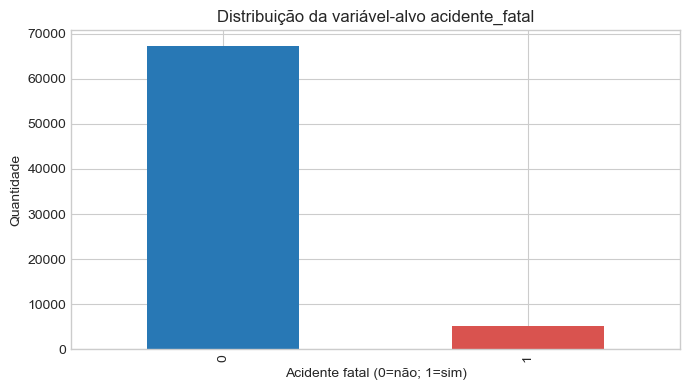

In [12]:
def ranking_categoria(base, coluna, n=10):
    return (base[coluna].value_counts(dropna=False).head(n)
            .rename_axis(coluna).reset_index(name="qtd"))

def taxa_fatal_por_categoria(base, coluna, min_registros=30):
    tab = base.groupby(coluna, dropna=False).agg(
        qtd_acidentes=("acidente_fatal", "size"),
        qtd_fatais=("acidente_fatal", "sum"),
        taxa_fatal=("acidente_fatal", "mean")
    ).reset_index()
    return tab[tab["qtd_acidentes"] >= min_registros].sort_values("taxa_fatal", ascending=False)

display(ranking_categoria(df, "causa_acidente"))
display(ranking_categoria(df, "tipo_acidente"))
display(taxa_fatal_por_categoria(df, "tipo_acidente").head(10))

ax = df["acidente_fatal"].value_counts().sort_index().plot(
    kind="bar", color=["#2878B5", "#D9534F"], figsize=(7, 4)
)
ax.set(title="Distribuição da variável-alvo acidente_fatal",
       xlabel="Acidente fatal (0=não; 1=sim)", ylabel="Quantidade")
plt.tight_layout()
plt.savefig(ARQUIVO_GRAFICO, dpi=150)
plt.show()

## Erros comuns no alvo

- **Inverter 0 e 1:** `np.where(mortos == 0, 1, 0)` inverteria o significado do alvo.
- **Usar feridos no lugar de mortos:** fatalidade é definida exclusivamente por `mortos >= 1`.
- **Não tratar nulos:** ausências em `mortos` podem gerar um alvo incorreto ou erros silenciosos.
- **Não conferir a distribuição:** a proporção de 0 e 1 deve ser validada após criar o alvo.

> Um erro no alvo contamina a EDA, o dashboard e a árvore de decisão.

## Erros comuns de data leakage

São proibidas na base modelável variáveis como `mortos`, `total_vitimas`, `indice_gravidade` e
`classificacao_acidente`. Elas revelam o próprio desfecho, criando um modelo aparentemente excelente,
mas circular e inválido. As variáveis proibidas são marcadas no dicionário antes da exportação.

## 9. Bases analítica e modelável

A base analítica preserva resultados e indicadores. A modelável contém apenas informações que
poderiam explicar o acidente e o alvo; campos que revelam diretamente a gravidade são proibidos.

In [4]:
base_analitica = df.copy()

variaveis_modelaveis = [
    "uf", "br_formatada", "municipio", "mes", "trimestre", "dia_semana",
    "dia_semana_num", "fim_de_semana", "hora", "faixa_horaria", "turno", "fase_dia",
    "causa_acidente", "tipo_acidente", "condicao_metereologica", "tipo_pista",
    "tracado_via", "uso_solo", "acidente_fatal"
]
base_modelavel = df[[c for c in variaveis_modelaveis if c in df.columns]].copy()

variaveis_proibidas = [
    "mortos", "feridos", "feridos_leves", "feridos_graves", "total_vitimas",
    "indice_gravidade", "acidente_grave", "classificacao_acidente"
]
dicionario_proibidas = pd.DataFrame([
    {"variavel": c,
     "descricao": "Variável de resultado ou derivada do desfecho; causa data leakage",
     "uso": "PROIBIDA NA MODELAGEM"}
    for c in variaveis_proibidas
])
dicionario_proibidas.to_csv(
    ARQUIVO_DICIONARIO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA
)

def verificar_data_leakage(base, proibidas):
    presentes = [c for c in proibidas if c in base.columns]
    if presentes:
        raise ValueError(f"Data leakage detectado: {presentes}")
    return "OK"

resultado_leakage = verificar_data_leakage(base_modelavel, variaveis_proibidas)

for coluna in base_modelavel.columns:
    if coluna == "acidente_fatal": continue
    if isinstance(base_modelavel[coluna].dtype, pd.StringDtype) or base_modelavel[coluna].dtype == "object":
        base_modelavel[coluna] = base_modelavel[coluna].fillna("IGNORADO")
    else:
        base_modelavel[coluna] = base_modelavel[coluna].fillna(-1)

assert base_modelavel.isna().sum().sum() == 0
print("Base analítica:", base_analitica.shape)
print("Base modelável:", base_modelavel.shape)
print("Data leakage:", resultado_leakage)

Base analítica: (72529, 30)
Base modelável: (72529, 10)
Data leakage: OK


## 10. Exportação e validação pós-exportação

As saídas usam `;` e `utf-8-sig`, combinação amigável ao Excel e ao Power BI. Depois de salvar,
os arquivos são reabertos e suas dimensões são testadas.

In [5]:
base_analitica.to_csv(ARQUIVO_BASE_ANALITICA, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
base_modelavel.to_csv(ARQUIVO_BASE_MODELAVEL, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

valid_analitica = pd.read_csv(ARQUIVO_BASE_ANALITICA, sep=SEPARADOR, encoding=ENCODING_SAIDA, low_memory=False)
valid_modelavel = pd.read_csv(ARQUIVO_BASE_MODELAVEL, sep=SEPARADOR, encoding=ENCODING_SAIDA, low_memory=False)
assert valid_analitica.shape == base_analitica.shape
assert valid_modelavel.shape == base_modelavel.shape
print("Analítica reaberta:", valid_analitica.shape)
print("Modelável reaberta:", valid_modelavel.shape)

Analítica reaberta: (72529, 30)
Modelável reaberta: (72529, 10)


## MINI-ENTREGA 5 — Duas Bases: Checkpoint Principal

**Base analítica:** criada, exportada e reaberta com dimensões validadas.  
**Base modelável:** criada sem data leakage, exportada e reaberta com `assert`.

A célula seguinte apresenta os nomes dos arquivos gerados e o resultado `OK` da função `verificar_data_leakage()`.

In [15]:
arquivos_checkpoint = pd.DataFrame([
    {"base": "Analítica", "arquivo": ARQUIVO_BASE_ANALITICA.name,
     "dimensao": str(valid_analitica.shape)},
    {"base": "Modelável", "arquivo": ARQUIVO_BASE_MODELAVEL.name,
     "dimensao": str(valid_modelavel.shape)},
])
resultado_leakage = verificar_data_leakage(valid_modelavel, variaveis_proibidas)
display(arquivos_checkpoint)
print("verificar_data_leakage:", resultado_leakage)
assert resultado_leakage == "OK"
assert valid_analitica.shape == base_analitica.shape
assert valid_modelavel.shape == base_modelavel.shape
print("MINI-ENTREGA 5 CONCLUÍDA COM SUCESSO.")

,base,arquivo,dimensao
0,Analítica,base_analitica_prf_2025.csv,"(72529, 44)"
1,Modelável,base_modelavel_prf_2025.csv,"(72529, 19)"


verificar_data_leakage: OK
MINI-ENTREGA 5 CONCLUÍDA COM SUCESSO.


## 11. Dicionário, decisões e resumo final

Esta etapa produz os documentos necessários para rastreabilidade e avaliação do projeto.

In [16]:
linhas_dic = [
    {"variavel": "ano", "descricao": "Ano extraído da data da ocorrência", "uso": "analise/modelagem"},
    {"variavel": "mes", "descricao": "Mês numérico da ocorrência", "uso": "analise/modelagem"},
    {"variavel": "trimestre", "descricao": "Trimestre da ocorrência", "uso": "analise/modelagem"},
    {"variavel": "fim_de_semana", "descricao": "1 para sábado/domingo; 0 nos demais dias", "uso": "analise/modelagem"},
    {"variavel": "turno", "descricao": "Madrugada, manhã, tarde, noite ou ignorado", "uso": "analise/modelagem"},
    {"variavel": "faixa_horaria", "descricao": "Faixa de três horas", "uso": "analise/modelagem"},
    {"variavel": "acidente_fatal", "descricao": "1 se mortos >= 1; caso contrário 0", "uso": "alvo"},
    {"variavel": "total_vitimas", "descricao": "Mortos + feridos leves + feridos graves", "uso": "analise/dashboard"},
    {"variavel": "acidente_grave", "descricao": "1 se houve morto ou ferido grave", "uso": "analise/dashboard"},
    {"variavel": "indice_gravidade", "descricao": "mortos*3 + feridos_graves*2 + feridos_leves", "uso": "analise/dashboard"},
    {"variavel": "br_formatada", "descricao": "BR no formato BR-000", "uso": "analise/modelagem"},
    {"variavel": "chave_localidade", "descricao": "UF + município + BR formatada", "uso": "analise/dashboard"},
]
dicionario = pd.concat([pd.DataFrame(linhas_dic), dicionario_proibidas], ignore_index=True)
dicionario.to_csv(ARQUIVO_DICIONARIO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

resumo_final = pd.DataFrame([
    {"item": "linhas_originais", "valor": dimensao_inicial[0]},
    {"item": "duplicidades_removidas", "valor": qtd_duplicadas},
    {"item": "linhas_base_analitica", "valor": len(base_analitica)},
    {"item": "colunas_base_analitica", "valor": base_analitica.shape[1]},
    {"item": "linhas_base_modelavel", "valor": len(base_modelavel)},
    {"item": "colunas_base_modelavel", "valor": base_modelavel.shape[1]},
    {"item": "acidentes_fatais", "valor": int(base_modelavel["acidente_fatal"].sum())},
    {"item": "taxa_global_acidente_fatal", "valor": base_modelavel["acidente_fatal"].mean()},
    {"item": "total_mortos", "valor": int(base_analitica["mortos"].sum())},
])
resumo_final.to_csv(ARQUIVO_RESUMO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

texto_decisoes = f'''# Decisões de tratamento — Módulo 4

## Data e hora da geração

{datetime.now().strftime('%Y-%m-%d %H:%M')}

## Regras adotadas

- Leitura com separador `{SEPARADOR}` e encoding de entrada `{encoding_usado}`.
- Nomes de colunas em minúsculas, sem acentos e com underline.
- Números convertidos com `pd.to_numeric(errors='coerce')`; vírgula decimal tratada em km, latitude e longitude.
- Datas e horários convertidos com `errors='coerce'`, tornando formatos inválidos valores ausentes verificáveis.
- Textos sem espaços nas extremidades, em maiúsculas e com vazios convertidos em nulos.
- Categorias relevantes ausentes preenchidas com `IGNORADO`.
- Nulos nas contagens de vítimas preenchidos com zero, conforme hipótese operacional do roteiro.
- Na base modelável, categóricas ausentes recebem `IGNORADO` e numéricas ausentes recebem `-1`.
- O alvo foi preservado: `acidente_fatal = 1` quando `mortos >= 1`; caso contrário, `0`.
- Foram removidas {qtd_duplicadas} duplicidades exatas.

## Justificativas metodológicas

- `IGNORADO` preserva a informação de ausência e evita eliminar ocorrências por falta de categoria.
- Zero nas contagens representa a hipótese operacional definida no roteiro; a regra não é aplicada indistintamente a outras variáveis.
- `-1` funciona como marcador numérico fora das categorias válidas e evita falhas na codificação e na árvore do Módulo 7.
- Mortos, feridos, indicadores de gravidade e classificação do acidente foram excluídos da base modelável porque revelam o desfecho e causariam data leakage.
- A base analítica preserva indicadores de resultado para EDA e dashboards; a modelável mantém apenas explicativas e o alvo.
- As saídas usam UTF-8 com BOM para facilitar a leitura no Excel e no Power BI.

## Arquivos gerados e caminhos

- `{ARQUIVO_BASE_ANALITICA.relative_to(RAIZ)}` — base completa para EDA e Power BI.
- `{ARQUIVO_BASE_MODELAVEL.relative_to(RAIZ)}` — base para modelagem sem data leakage.
- `{ARQUIVO_DICIONARIO.relative_to(RAIZ)}` — dicionário das variáveis criadas.
- `{ARQUIVO_RESUMO.relative_to(RAIZ)}` — resumo numérico da preparação.
- `{ARQUIVO_GRAFICO.relative_to(RAIZ)}` — gráfico de distribuição do alvo.
- `{ARQUIVO_DECISOES.relative_to(RAIZ)}` — este registro de decisões.
- `README.md` — objetivo, execução, bases e observação sobre data leakage.
'''
ARQUIVO_DECISOES.write_text(texto_decisoes, encoding="utf-8")
display(dicionario)
display(resumo_final)

,variavel,descricao,uso
0,ano,Ano extraído da data da ocorrência,analise/modelagem
1,mes,Mês numérico da ocorrência,analise/modelagem
2,trimestre,Trimestre da ocorrência,analise/modelagem
3,fim_de_semana,1 para sábado/domingo; 0 nos demais dias,analise/modelagem
4,turno,"Madrugada, manhã, tarde, noite ou ignorado",analise/modelagem
5,faixa_horaria,Faixa de três horas,analise/modelagem
6,acidente_fatal,1 se mortos >= 1; caso contrário 0,alvo
7,total_vitimas,Mortos + feridos leves + feridos graves,analise/dashboard
8,acidente_grave,1 se houve morto ou ferido grave,analise/dashboard
9,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard


,item,valor
0,linhas_originais,72529.000000
1,duplicidades_removidas,0.000000
2,linhas_base_analitica,72529.000000
3,colunas_base_analitica,44.000000
4,linhas_base_modelavel,72529.000000
5,colunas_base_modelavel,19.000000
6,acidentes_fatais,5210.000000
7,taxa_global_acidente_fatal,0.071833
8,total_mortos,6043.000000


## Boas práticas em notebooks

- **Executar do início ao fim:** reiniciar o kernel e executar todas as células antes da entrega.
- **Células em ordem lógica:** o avaliador deve reproduzir o projeto sem reorganizar o notebook.
- **Comentários curtos e objetivos:** explicar as decisões, e não apenas repetir o código.
- **Sem caminhos pessoais fixos:** a raiz usa `Path(".").resolve()`, mantendo a portabilidade.

## 12. Checklist de conclusão

Se a próxima célula exibir todos os itens como `True`, a entrega está tecnicamente completa.

In [17]:
checklist = {
    "01_notebook_executa_em_ordem": True,  # alcançar esta célula comprova as anteriores
    "02_bases_exportadas_e_reabertas": (
        ARQUIVO_BASE_ANALITICA.exists() and ARQUIVO_BASE_MODELAVEL.exists()
        and valid_analitica.shape == base_analitica.shape
        and valid_modelavel.shape == base_modelavel.shape
    ),
    "03_readme_criado": ARQUIVO_README.exists(),
    "04_decisoes_registradas": ARQUIVO_DECISOES.exists(),
    "04_leakage_ausente_OK": verificar_data_leakage(base_modelavel, variaveis_proibidas) == "OK",
    "dicionario_com_proibidas": set(variaveis_proibidas).issubset(set(dicionario["variavel"])),
    "sem_nulos_na_modelavel": base_modelavel.isna().sum().sum() == 0,
}
display(pd.Series(checklist, name="concluido").to_frame())
assert all(checklist.values()), "Há itens pendentes no checklist."
print("Projeto concluído e validado com sucesso.")

,concluido
01_notebook_executa_em_ordem,True
02_bases_exportadas_e_reabertas,True
03_readme_criado,True
04_decisoes_registradas,True
04_leakage_ausente_OK,True
dicionario_com_proibidas,True
sem_nulos_na_modelavel,True


Projeto concluído e validado com sucesso.
